<a href="https://colab.research.google.com/github/marcelalozano27-ship-it/Text-analytics-practice-/blob/main/Airline_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
import re
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from bs4 import BeautifulSoup


In [39]:
url = "https://raw.githubusercontent.com/marcelalozano27-ship-it/text-analytics-spring-2026/main/BA_AirlineReviews.csv"
df = pd.read_csv(url)

df.head()

,Unnamed: 0,OverallRating,ReviewHeader,Name,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,DateFlown,SeatComfort,CabinStaffService,GroundService,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity
0,0,1.0,"""Service level far worse then Ryanair""",L Keele,19th November 2023,True,"4 Hours before takeoff we received a Mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time. So did the capacity of the Heathrow Airport really hit British Airways by surprise, 4h before departure? Anyhow - we took the one hour delay so what - but then we have been forced to check in our Hand luggage. I travel only with hand luggage to avoid waiting for the ultra slow processing of the checked in luggage. Overall 2h later at home than planed, with really no reason, just due to incompetent people. Service level far worse then Ryanair and triple the price. Really never again. Thanks for nothing.",Couple Leisure,Economy Class,London to Stuttgart,November 2023,1.0,1.0,1.0,1.0,no,NaN,NaN,NaN,NaN
1,1,3.0,"""do not upgrade members based on status""",Austin Jones,19th November 2023,True,"I recently had a delay on British Airways from BRU to LHR that was due to staff shortages. They announced that there was a 2 hour holding delay but they would board us immediately in hopes of clearing the gate and leaving early. We had to wait the full 2 hours inside the airplane. The plane was old, dirty, had no power at the seats. The staff provided a small bag of pretzels and 250ml of water to the passengers for 2 hour delay and 2 hour flight. There were no options to purchase food or drink. There were no entertainment options available. I am a OneWorld emerald elite member but they do not upgrade members based on status. First class lounges at Heathrow are overcrowded, understaffed and poorly equipped. The help desk is completely unhelpful when an error arises with delays and cancellations - even when having the top status. The Avios points system has been devalued to near worthlessness and requires fees to book reward that nearly equal the price of the revenue ticket. British has lost its way in recent years and has a moved from a world-class airline to a budget airline with much worse service and timeliness than Ryanair or EasyJet.",Business,Economy Class,Brussels to London,November 2023,2.0,3.0,1.0,2.0,no,A320,1.0,2.0,2.0
2,2,8.0,"""Flight was smooth and quick""",M A Collie,16th November 2023,False,"Boarded on time, but it took ages to get to the runway due to congestion. Flight was smooth and quick. Snack and drinks were good for a short flight. Landed only about ten minutes late. One bag of three left in London, forms quickly filled in, and the bag was delivered the next morning.",Couple Leisure,Business Class,London Heathrow to Dublin,November 2023,3.0,3.0,4.0,3.0,yes,A320,4.0,NaN,NaN
3,3,1.0,"""Absolutely hopeless airline""",Nigel Dean,16th November 2023,True,"5 days before the flight, we were advised by BA that it had been cancelled and asked us to rebook. There were flights 1 hour before and 1 hour after our original flight but they made us take one 3 hours earlier. Our original ticket (and the return flight a week later) included a checked bag. When we arrive at Heathrow to check in we are told our ticket doesn't included a bag and we will have to pay 75 pounds each to take them. We explained that the original ticket had the bags and when they checked the system they confirmed that it did- but not this one! They would make no effort to sort it out and just told us to pay up or they would remove us from the flight. So we had no choice but to pay up, thinking it should be pretty easy to get a refund. 15 months and 10 emails later we have still not seen a penny. Every time I ask where my refund is and state how long we have been waiting I get an inane email saying some departments take longer than others to respond! Absolutely

In [40]:
print(df.info)
print(df.describe)
print(df.dtypes)

<bound method DataFrame.info of       Unnamed: 0  OverallRating                              ReviewHeader  \
0              0            1.0    "Service level far worse then Ryanair"   
1              1            3.0  "do not upgrade members based on status"   
2              2            8.0             "Flight was smooth and quick"   
3              3            1.0             "Absolutely hopeless airline"   
4              4            1.0        "Customer Service is non existent"   
...          ...            ...                                       ...   
3696        3696            1.0           British Airways customer review   
3697        3697            9.0           British Airways customer review   
3698        3698            5.0           British Airways customer review   
3699        3699            4.0           British Airways customer review   
3700        3700            4.0           British Airways customer review   

                  Name            Datetime 

In [41]:
print("The data set contains the following columns:\n", df.columns)
print(df.index)

The data set contains the following columns:
 Index(['Unnamed: 0', 'OverallRating', 'ReviewHeader', 'Name', 'Datetime',
       'VerifiedReview', 'ReviewBody', 'TypeOfTraveller', 'SeatType', 'Route',
       'DateFlown', 'SeatComfort', 'CabinStaffService', 'GroundService',
       'ValueForMoney', 'Recommended', 'Aircraft', 'Food&Beverages',
       'InflightEntertainment', 'Wifi&Connectivity'],
      dtype='object')
RangeIndex(start=0, stop=3701, step=1)


### Exploratory Data Analysis

In [42]:
missing=df.isna().sum().sort_values(ascending=False)
missing_pct=(missing/len(df)*100).round(2)
print("Percentage of missing values in each column:\n", missing_pct[missing_pct>0])

Percentage of missing values in each column:
 Wifi&Connectivity        83.54
Aircraft                 48.07
InflightEntertainment    31.07
GroundService            22.86
DateFlown                21.02
Route                    20.94
TypeOfTraveller          20.83
Food&Beverages           10.43
CabinStaffService         3.43
SeatComfort               3.13
OverallRating             0.14
SeatType                  0.05
ValueForMoney             0.03
dtype: float64


In [43]:
#Determine the length
text=df["ReviewBody"].astype("string")

text=text.fillna("")

lengths=text.map(len)

minlength=int(lengths.min())
maxlength=int(lengths.max())
meanlength=float(lengths.mean())
medianlength=float(lengths.median())

print(f"Statistics of Review Text Length: \n Minimum Length: {minlength}\n Maximum Length: {maxlength}\n Mean Length: {meanlength}\n Median Length: {medianlength}")

Statistics of Review Text Length: 
 Minimum Length: 83
 Maximum Length: 3529
 Mean Length: 881.2842475006755
 Median Length: 736.0


In [44]:
#Show sample text
for review in text.sample(10, random_state=1):
  print(review[:150])

Port of Spain to Gatwick via St. Lucia was a good experience. I don't have any complaints regarding the seat quality or flight attendants, who did a v
Delayed just for a change. Poor communication. British Airways sells premium prices flight tickets and delivers no better than a low cost airline. Cus
Flew Belfast to London with British Airways. Stressful day started with a 2.5 hours delay for the morning flight at 7am. As an apology, they sold us t
Sydney to London via Singapore. It has been a very long time since I was on a long haul with BA of more than 9 hours. Last year had a relative sprint 
Istanbul to London Heathrow. I am a frequent flyer between Turkey and Canada. I got first time flight by British Airways. I feel it was the worst airl
London to Vancouver. Check in agent very helpful in searching out seat options. Very smooth process. The disappointment was the receptionist at the Ga
Our Good Friday flight was delayed by 5hours, STD 12.50 ATD 18.00 TO Durban, South Africa from

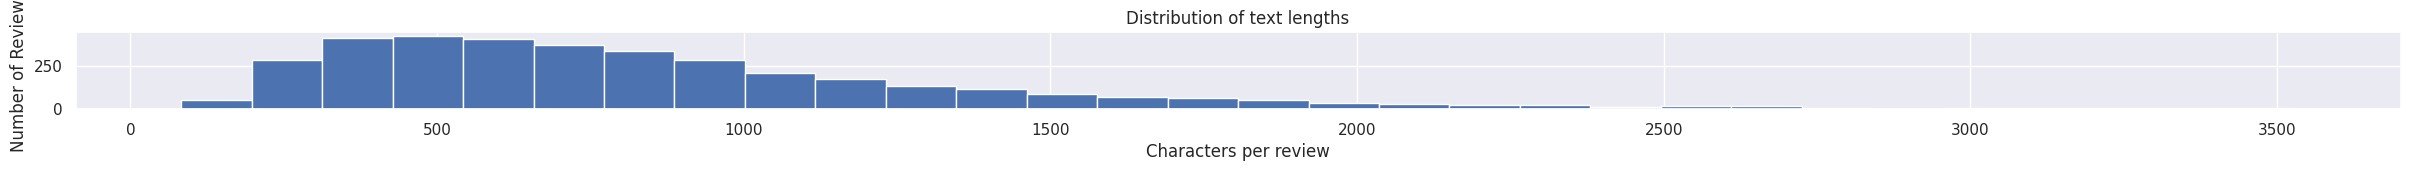

In [45]:
plt.hist(lengths, bins=30)
plt.title("Distribution of text lengths")
plt.xlabel("Characters per review")
plt.ylabel("Number of Reviews")
plt.show()

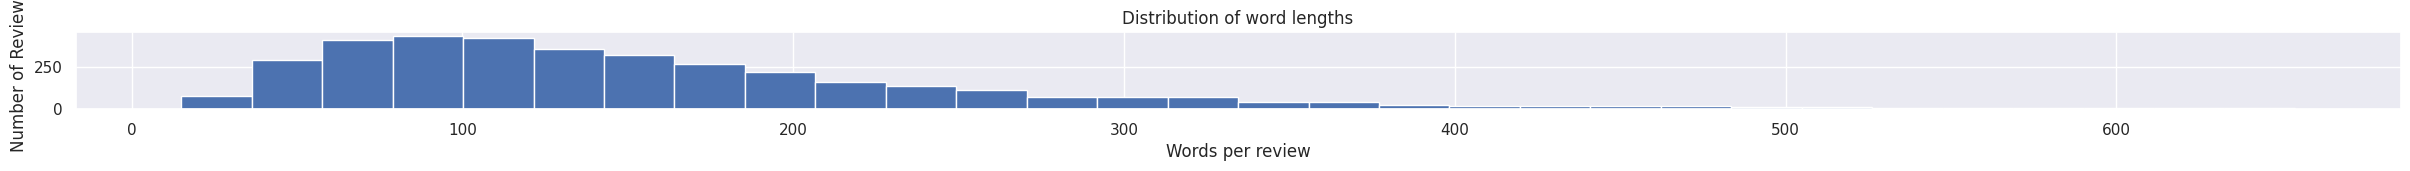

In [46]:
wordcounts=text.str.split().str.len()
plt.hist(wordcounts, bins=30)
plt.title("Distribution of word lengths")
plt.xlabel("Words per review")
plt.ylabel("Number of Reviews")
plt.show()

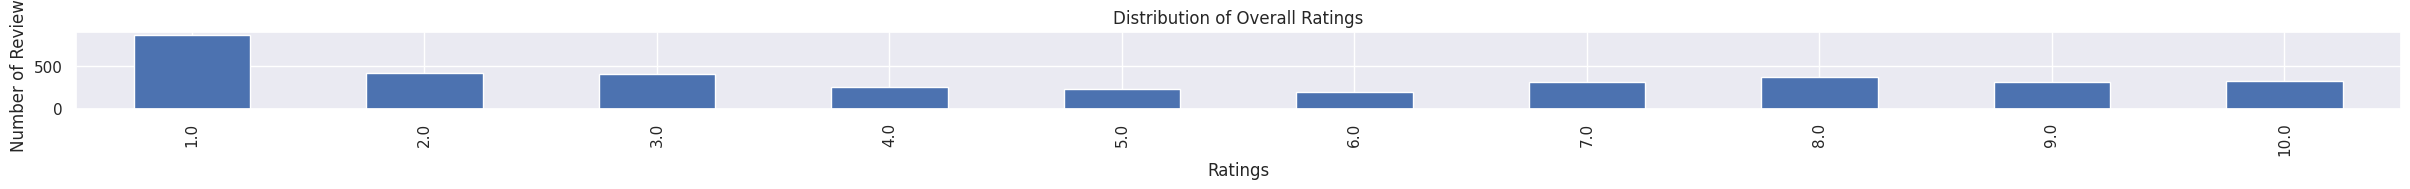

In [47]:
df['OverallRating'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Overall Ratings")
plt.xlabel("Ratings")
plt.ylabel("Number of Reviews")
plt.show()

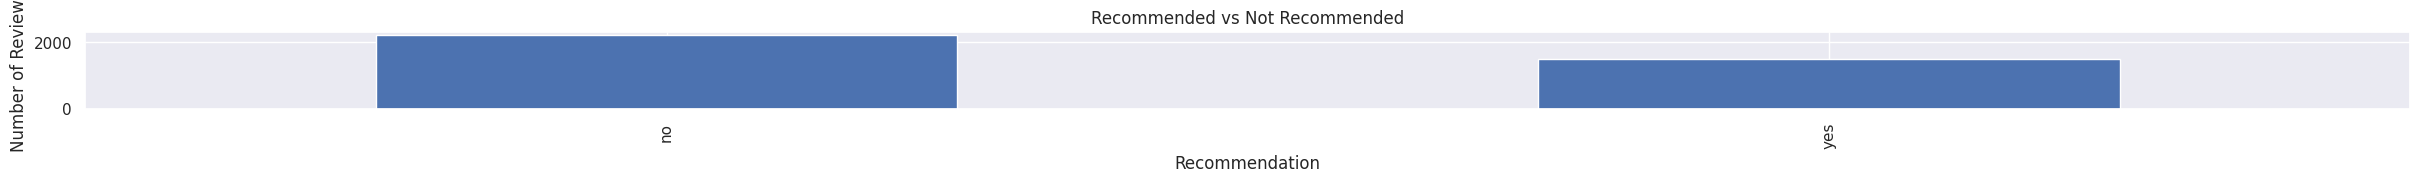

In [48]:
df['Recommended'].value_counts().plot(kind='bar')
p=plt.title("Recommended vs Not Recommended")
plt.xlabel("Recommendation")
plt.ylabel("Number of Reviews")
plt.show()

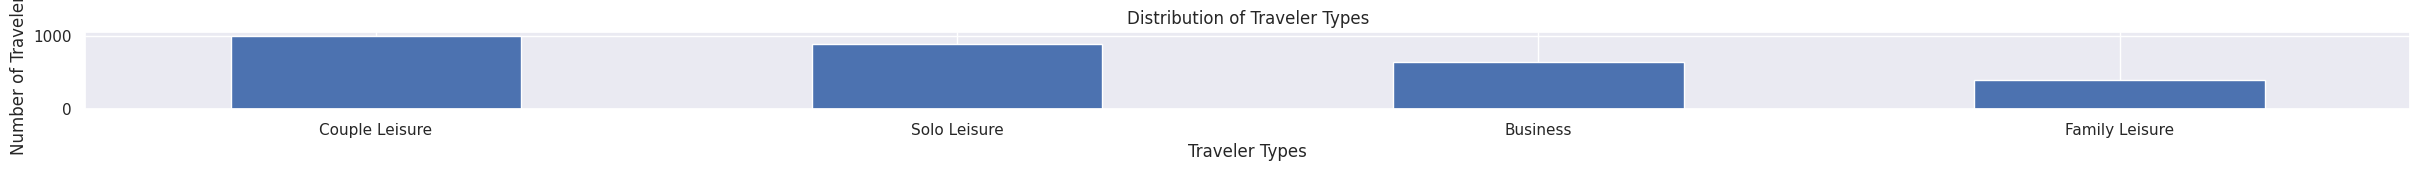

In [49]:
df['TypeOfTraveller'].value_counts().plot(kind='bar')
p=plt.title("Distribution of Traveler Types")
plt.xlabel("Traveler Types")
plt.ylabel("Number of Travelers")
plt.xticks(rotation=0)
plt.show()

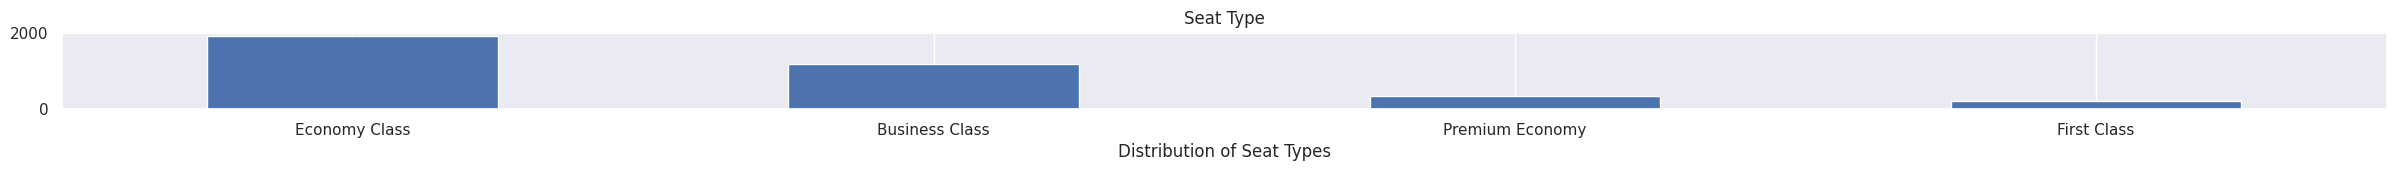

In [50]:
df['SeatType'].value_counts().plot(kind='bar')
p=plt.title("Seat Type")
plt.xlabel("Distribution of Seat Types")
plt.xticks(rotation=0)
plt.show()

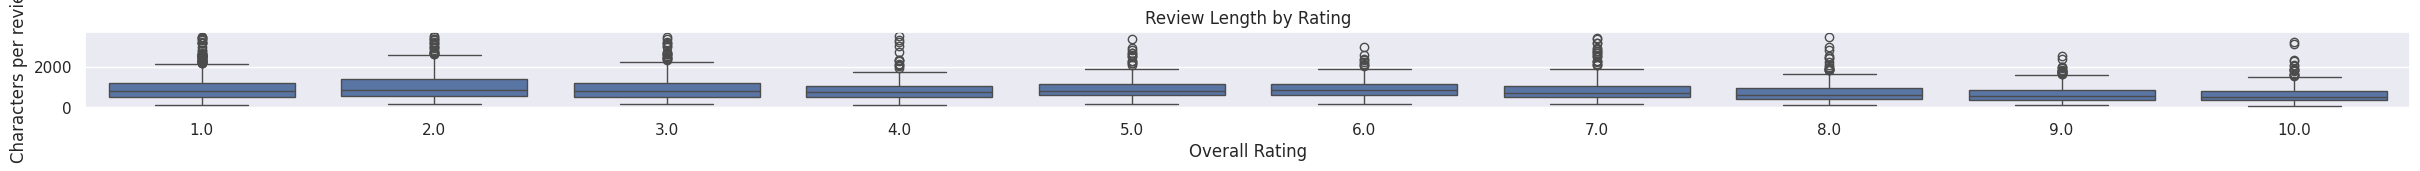

In [51]:
sns.boxplot(x=df['OverallRating'], y=lengths)
plt.title("Review Length by Rating")
plt.xlabel("Overall Rating")
plt.ylabel("Characters per review")
plt.show()


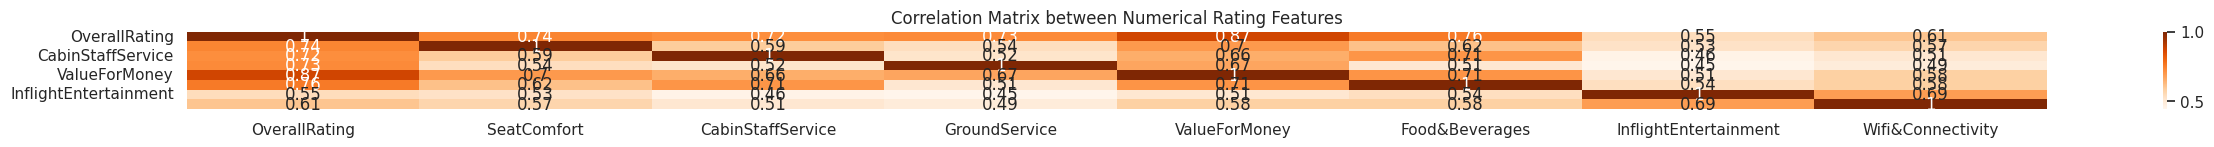

In [52]:
numeric_cols=["OverallRating", "SeatComfort", "CabinStaffService", "GroundService", "ValueForMoney", "Food&Beverages", "InflightEntertainment", "Wifi&Connectivity"]

corr=df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="Oranges")
plt.title("Correlation Matrix between Numerical Rating Features")
plt.show()

From our initial analysis of the data, the reviews are written in English and in full sentences. I used a random sample of 400 reviews to get a better idea of the amount of reviews with special characters, URLs, hashtags or HTML tags and found none.

There are also no noted formatting problems and it will be enough to just perform some minor cleaning like lowercasing, removing punctuation and trimming white space.

The main pattern noticed is that reviews are long narratives.

In [53]:
import re

# Simple contraction dictionary
contractions = {
    "don't": "do not",
    "can't": "cannot",
    "won't": "will not",
    "i'm": "i am",
    "it's": "it is",
    "that's": "that is",
    "didn't": "did not",
    "doesn't": "does not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not"
}

def clean_text(t):
    t = str(t)

    # remove HTML tags
    t = re.sub(r"<.*?>", " ", t)

    # remove URLs
    t = re.sub(r"http\S+|www\S+", " ", t)

    # lowercase
    t = t.lower()

    # expand contractions
    for c in contractions:
        t = t.replace(c, contractions[c])

    # remove numbers
    t = re.sub(r"\d+", " ", t)

    # remove extra whitespace
    t = re.sub(r"\s+", " ", t).strip()

    return t

df["clean_text"] = df["ReviewBody"].apply(clean_text)
examples = df[["ReviewBody", "clean_text"]].sample(3)

for raw, cleaned in zip(examples["ReviewBody"], examples["clean_text"]):
    print("\n==============================")
    print("Before:")
    print(str(raw)[:300])

    print("\nAfter:")
    print(str(cleaned)[:300])

    print("\nWhy this matters:")
    print("Removed HTML, URLs, special characters, lowercased, and cleaned whitespace.")



Before:
Antigua to Gatwick. One of the worst business class experience. Entertainment system didn't work and asked the crew for solution and their reply was sorry sir there is no solution. Service super slow 2-3 crew to serve 48 business class passengers. Food bad, beef over cooked, mashed potatoes dry and 

After:
antigua to gatwick. one of the worst business class experience. entertainment system did not work and asked the crew for solution and their reply was sorry sir there is no solution. service super slow - crew to serve business class passengers. food bad, beef over cooked, mashed potatoes dry and sala

Why this matters:
Removed HTML, URLs, special characters, lowercased, and cleaned whitespace.

Before:
Rating : 10/10 Cabin Flown Economy Value for Money Seat Comfort Staff Service Catering Entertainment Recommended

After:
rating : / cabin flown economy value for money seat comfort staff service catering entertainment recommended

Why this matters:
Removed HTML, URLs, special 

You can refresh the text a few times to confirm that even when generating a new random three examples, they all are being cleaned in a consistent way.

In [54]:
post_clean_empty_cell=(df["clean_text"].str.strip()=="").sum()
print(" Reviews without a Body:", post_clean_empty_cell)


 Reviews without a Body: 0


In [55]:
# Count words in cleaned text
cleanedtxtwordcounts= df["clean_text"].str.split().str.len()

subtwowords = (cleanedtxtwordcounts <= 2).sum()
print("Very short cleaned reviews (1–2 words):", subtwowords)


Very short cleaned reviews (1–2 words): 0


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


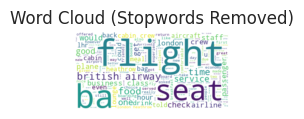

In [56]:
import nltk
import nltk
nltk.download( 'punkt')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download resources (run once)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab') # Added to resolve LookupError

# Base stop words
stop_words = set(stopwords.words('english'))

# Custom airline stop words
custom_stopwords = {
    "https", "http", "co", "www", "rt", "RT",
    "aren", "couldn", "didn", "doesn", "don", "hadn", "hasn", "haven",
    "isn", "let", "ll", "mustn", "re", "shan", "shouldn", "ve", "wasn",
    "weren", "won", "wouldn"
}

stop_words = stop_words.union(custom_stopwords)

# Function to remove stop words
def remove_stopwords(text):
    text = str(text).lower()
    words = word_tokenize(text)
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

# Apply cleaning
df["cleaned_review"] = df["clean_text"].apply(remove_stopwords)

# Preview
print(df[["clean_text", "cleaned_review"]].head())

from wordcloud import WordCloud
from wordcloud import STOPWORDS
full_text = " ".join(df["clean_text"].fillna("").astype(str))
cloud_no_stopword = WordCloud(background_color='white', stopwords=stop_words).generate(full_text)

plt.imshow(cloud_no_stopword, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud (Stopwords Removed)")
plt.show()

In [57]:
!pip -q install transformers torch

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "bhadresh-savani/distilbert-base-uncased-emotion"
)

# Take one example review
example_text = df["ReviewBody"].fillna("").iloc[0]

# Tokenize it
encoded = tokenizer(
    example_text,
    truncation=True,
    padding=True,
    return_tensors="pt"
)

print("Token IDs:", encoded["input_ids"][0][:20])
print("Attention mask:", encoded["attention_mask"][0][:20])


Token IDs: tensor([  101,  1018,  2847,  2077, 19744,  2057,  2363,  1037,  5653,  5517,
         1037, 26483,  4471,  2008,  2045,  2024, 20461,  2015,  2000,  2022])
Attention mask: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In [58]:
def vader_prep(t):
    t = str(t)
    t = re.sub(r"<.*?>", " ", t)             # remove HTML
    t = re.sub(r"http\S+|www\S+", " ", t)    # remove URLs
    t = re.sub(r"\s+", " ", t).strip()       # normalize spaces
    t = re.sub(r"\s+", " ", t).strip()
    return t

df["vader_text"] = df["ReviewBody"].fillna("").apply(vader_prep)

df["textblob_text"] = df["ReviewBody"].fillna("").apply(clean_text)

# Vader and the transformer can use similarly cleaned data
df['transformertext']=df['vader_text']

##Vader

In [59]:
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [60]:

if "OverallRating" in df.columns:
    airline_best_worst = df[
        (df["OverallRating"] == 10) |
        (df["OverallRating"] == 1)
    ].reset_index(drop=True)
else:
    airline_best_worst = df.copy()

print("\nBest/Worst sample size:", len(airline_best_worst))

examples = airline_best_worst.sample(3, random_state=1)

for text in examples["vader_text"]:
    print("\n==============================")
    print("Example review:")
    print(text[:500])
    print("\nVADER scores:")
    print(sid.polarity_scores(text))



Best/Worst sample size: 1195

Example review:
Couldn’t book in online. Arrived at check in to find we had been bumped off due to overselling. No BA staff available. Very helpful Gatwick staff got us a bus to LHR and a flight to Toulouse. Had knock in effect on our car booking and sharing as the rest of family had been able yo board original flight. Airlines should be legally stopped from selling seats twice.

VADER scores:
{'neg': 0.079, 'neu': 0.792, 'pos': 0.129, 'compound': 0.5709}

Example review:
Hong Kong to London. I booked a return ticket for my sister though BA, provided travel document details they required. However when we got to the airport we found out my sisters middle name was not on her ticket and it therefore didn't match her passport name. They refused to let her fly, after much hassle and my sister getting a temporary visa, they enable her to fly. However, once landing in London I acknowledged that she may have the same problem flying back to Taiwan. Igot in contact

In [61]:
print("Examples of Reviews likely to be Positive:\n")
for review in df[df["OverallRating"] == 10]["ReviewBody"].head():
    print("-", review, "\n")

print("Examples of Reviews likely to be Negative:\n")
for review in df[df["OverallRating"] == 1]["ReviewBody"].head():
    print("-", review, "\n")


Examples of Reviews likely to be Positive:

- Excellent service levels, proactive crew and superb food and beverages. I found all aspects of the service to be superior to BA business class, even the new BA Club Suites. First Class felt exclusive, the dedicated crew were clearly used to working the premium cabin, enjoying their work, were proactive, friendly, very respectful and the food and beverage offering a considerable step up from business class. The seat, with sliding double doors was spacious, well designed and very comfortable.  British Airways offered a solid First Class service, from Concorde Lounge to boarding (which was actually by group number for a change) to the very warm and genuine welcome on boarding. A consistent, solid, comfortable service from start to finish and if the price was right, I would not hesitate to book First Class with British Airways again. 

- Good domestic flight operated by BA Cityflyer. Ground service at check-in Edinburgh airport was particularly


Full Review: BA has a real problem with boarding it's flights. Those who get on first fill the luggage bins with 2 bags, one of which is supposed to be small and under seat only. Cabin staff don't bother implementing their own rules. Subsequent passengers mill up and down the aisle, bumping into each other, searching for space. Boarding this flight took an hour as a result of this nonsense. The incoming flight was late already so our 90 minute flight was 90 minutes late.

Overall VADER Sentiment Score: -0.5844


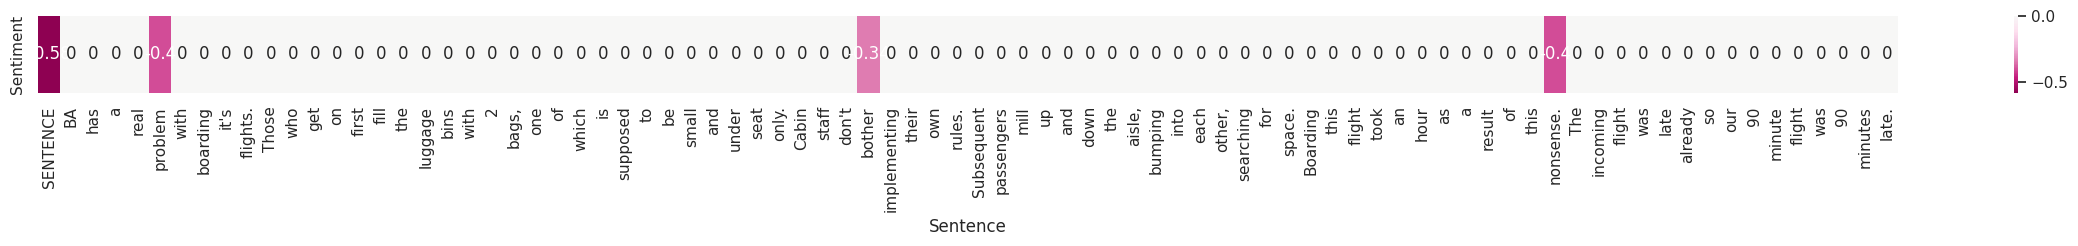

In [62]:
sns.set(rc={'figure.figsize':(30,1)})

def visualise_sentiments(data):
  sns.heatmap(pd.DataFrame(data).set_index("Sentence").T,center=0, annot=True, cmap = "PiYG")
visualise_sentiments({
    "Sentence":["SENTENCE"] + airline_best_worst.loc[12, 'vader_text'].split(),
    "Sentiment":[sid.polarity_scores(airline_best_worst.loc[12, 'vader_text'])["compound"]]
    + [sid.polarity_scores(word)["compound"] for word in airline_best_worst.loc[12, 'vader_text'].split()]})


idx = 12
review_text = airline_best_worst.loc[idx, "vader_text"]
overall_score = sid.polarity_scores(review_text)["compound"]
print("\nFull Review:", review_text)
print("\nOverall VADER Sentiment Score:", overall_score)

In [63]:
df['compound'] = df['ReviewBody'].apply(lambda x: sid.polarity_scores(str(x))['compound'])


##TextBlob

In [64]:
from textblob import TextBlob
def detect_sentiment(text):

    #Convert text into a TextBlob object
    blob = TextBlob(text)

    return blob.sentiment.subjectivity

airline_best_worst.loc[31,"textblob_text"]

'british airways has a total lack of respect for its customers. i was booked to fly from frankfurt main to london city airport, and just a couple of hours before the scheduled departure the flight was suddenly cancelled by ba without explanation, when i was already at the airport. the worst thing was the utter callousness that staff showed towards customers. the ground staff’s attitude was that they are merely third party agents, not ba employees, and therefore they quickly washed their hands of us all, telling us we had to contact ba directly via phone if we wanted help. they couldn’t even provide us a phone number, telling us to look it up on ba.com ! so ba abandoned its passengers. they did tell us that the ba departure to heathrow had also been cancelled, meaning there would be no further ba flight from frankfurt to london that day (although other airlines were still operating the route- but ba refused to rebook us on them). the reason given for both cancellations was “technical re

In [65]:
blob = TextBlob(airline_best_worst.loc[31,"textblob_text"])
print(blob)
print()
print(blob.sentiment)

british airways has a total lack of respect for its customers. i was booked to fly from frankfurt main to london city airport, and just a couple of hours before the scheduled departure the flight was suddenly cancelled by ba without explanation, when i was already at the airport. the worst thing was the utter callousness that staff showed towards customers. the ground staff’s attitude was that they are merely third party agents, not ba employees, and therefore they quickly washed their hands of us all, telling us we had to contact ba directly via phone if we wanted help. they couldn’t even provide us a phone number, telling us to look it up on ba.com ! so ba abandoned its passengers. they did tell us that the ba departure to heathrow had also been cancelled, meaning there would be no further ba flight from frankfurt to london that day (although other airlines were still operating the route- but ba refused to rebook us on them). the reason given for both cancellations was “technical rea

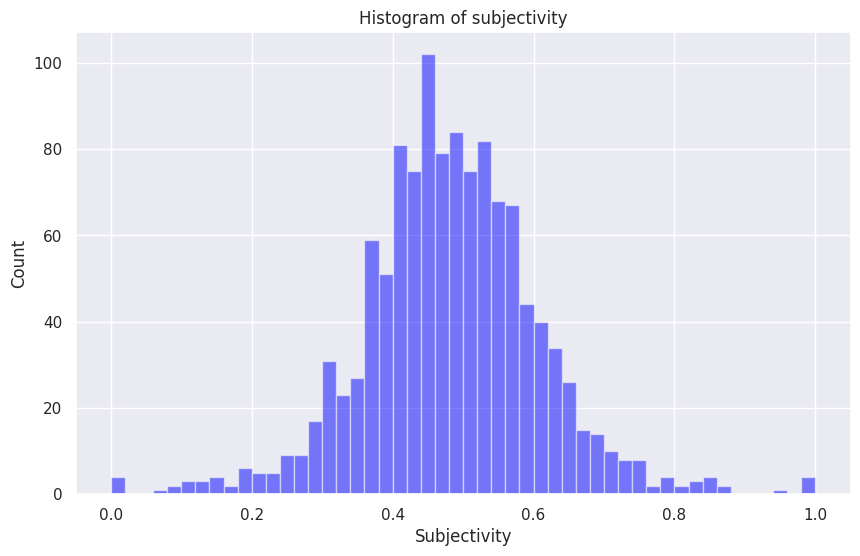

In [66]:
airline_best_worst["subjectivity"] = airline_best_worst.textblob_text.apply(detect_sentiment)
num_bins = 50
plt.figure(figsize=(10,6))
n, bins, patches = plt.hist(airline_best_worst.subjectivity, num_bins, facecolor='blue', alpha=0.5)
plt.xlabel('Subjectivity')
plt.ylabel('Count')
plt.title('Histogram of subjectivity')
plt.show()

##Transformers Model

In [67]:
from transformers import pipeline
classifier = pipeline("text-classification",model='bhadresh-savani/distilbert-base-uncased-emotion', return_all_scores=True)
prediction = classifier(airline_best_worst.loc[31,"transformertext"])

print(prediction)
print(airline_best_worst.loc[31,"ReviewBody"])

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'anger', 'score': 0.9756035208702087}]
British Airways has a total lack of respect for its customers. I was booked to fly from Frankfurt Main to London City Airport, and just a couple of hours before the scheduled departure the flight was suddenly cancelled by BA without explanation, when I was already at the airport. The worst thing was the utter callousness that staff showed towards customers. The ground staff’s attitude was that they are merely third party agents, not BA employees, and therefore they quickly washed their hands of us all, telling us we had to contact BA directly via phone if we wanted help. They couldn’t even provide us a phone number, telling us to look it up on ba.com ! So BA abandoned its passengers. They did tell us that the BA departure to Heathrow had also been cancelled, meaning there would be no further BA flight from Frankfurt to London that day (although other airlines were still operating the route- but BA refused to rebook us on them). The reas

In [73]:
#I am keeping 100 random samples for consistency when comparing models
sample_100 = df.sample(100, random_state=1).copy().reset_index(drop=True)
sample_100.to_csv("sampleairlinereviews.csv", index=False)


In [69]:
sample_100["vader_compound"]=sample_100["vader_text"].apply(lambda x: sid.polarity_scores(x)["compound"])
def vader_label(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

sample_100["vader_pred"] = sample_100["vader_compound"].apply(vader_label)


In [70]:
sample_100["textblob_polarity"] = sample_100["textblob_text"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)
def textblob_label(score):
    if score > 0.1:
        return "positive"
    elif score < -0.1:
        return "negative"
    else:
        return "neutral"

sample_100["textblob_pred"] = sample_100["textblob_polarity"].apply(textblob_label)


In [71]:
def transformer_label(text):
    pred = classifier(text)

    # unwrap outer list
    pred = pred[0]

    # get highest scoring emotion
    top = max(pred, key=lambda x: x["score"])["label"]

    # map emotion → sentiment
    if top in ["joy", "love", "surprise"]:
        return "positive"
    elif top in ["anger", "fear", "sadness"]:
        return "negative"
    else:
        return "neutral"



In [72]:
sample_100["ground_truth"] = ""
for i, row in sample_100.iterrows():
    print("\n===================================")
    print("Index:", i)
    print("Review:\n", row["ReviewBody"][:500])

    label = input("Enter sentiment (positive / negative / neutral): ").strip().lower()

    # simple validation
    while label not in ["positive", "negative", "neutral"]:
        label = input("Please enter: positive, negative, or neutral: ").strip().lower()

    sample_100.loc[i, "ground_truth"] = label




Index: 0
Review:
 Port of Spain to Gatwick via St. Lucia was a good experience. I don't have any complaints regarding the seat quality or flight attendants, who did a very good job during the flight on keeping the passengers safe and serving meals and drinks. The seat was comfortable enough, a bit wider than on low cost flights, I had extra space and as I noticed the leg room between seats was regular. I had a seat behind the bulkhead with enough leg room. There was a minor issue, the flight had a stop at St. Luc


KeyboardInterrupt: Interrupted by user